# Notebook dedicated to analyzing single bunch instabilities

### Imports and functions

In [6]:
!pip install seaborn


In [7]:
# import libraries
import os
import json
import h5py
from astropy.table import Table, vstack
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import seaborn as sns
import numpy as np
from scipy import fftpack

In [8]:
def extract3_(filename):
    f = h5py.File(filename, "r")
    f.keys()
    key1 = 'mean_x_array'
    key2 = 'sigma_z_array'
    key3 = 'alpha'
    key4 = 'n_turns'
    key5 = 'epsn_y_array'
    key6 = 'sigma_z'
    key7 = 'sigma_dp_array'
    keys = [key1, key2, key3, key4, key5, key6, key7]
    t = Table()
    for key in keys:
        if key == 'epsn_y_array':
            t[key] = f[key][()] * 1e+4
        else:
            t[key] = f[key][()]
    t['epsn_y'] = t['epsn_y_array'][0]
    t['turns'] = np.arange(len(t))
    return t
    # return t[0:30000] # limit to 60000 turns

In [9]:
#
def extract1_(filename):
    ''''
    Function that extracts output results and input variables from all h5 results files
'''
    t = Table()
    # filename = list_files[0]
    f = h5py.File(filename, "r")
    no_key = ['Nx_of_z', 'Ny_of_z', 'epsn_x', 'epsn_y', 'eq_emit_x', 'eq_emit_y', 'x_of_z', 'y_of_z']#, 'sigma_z']
    for key in f.keys():
        if key not in no_key:
            data = f[key][()]
            if key in ['E_loss', 'energy']:
                unit = u.GeV
            elif 'eps' in key:
                unit = u.m
            elif key in 'V_RF':
                unit = u.MV
            elif 'sigma_z' in key:
                unit = u.mm
            else:
                unit = 1
            key1 = key.replace('array', 'final')
            key2 = 'input_' + key.replace('_array', '')
            try :
                if len(data)>1:
                    t[key1] = data[-1] * unit
                    t[key2] = data[0] * unit
            except:
                t[key2] = [data] * unit
        else:
            pass

    input_file = filename.replace('data/statistics_and_parameters.h5', 'input_conf.json')
    f = open(input_file)
    d = json.load(f)
    for key in d.keys():
        if key not in ['sigma_z']:
            key2 = 'input_' + key
            if 'epsn_y' in key:
                t[key2] = [d[key]] * u.m
            elif key == 'frequency':
                t[key2] = [d[key]] * u.Hz
            else:
                t[key2] = [d[key]]
    return t


In [10]:
def extract4_(filename):
    f = h5py.File(filename, "r")
    f.keys()
    key1 = 'mean_x_array'
    key2 = 'sigma_z_array'
    key3 = 'alpha'
    key4 = 'n_turns'
    key5 = 'epsn_y_array'
    key6 = 'sigma_z'
    key7 = 'sigma_dp_array'
    keys = [key1, key2, key3, key4, key5, key6, key7]
    t = Table()
    for key in keys:
        if key == 'epsn_y_array':
            t[key] = f[key][()] * 1e+4
        else:
            t[key] = f[key][()]
    t['epsn_y'] = t['epsn_y_array'][0]
    t['turns'] = np.arange(len(t))
    t2 = extract1_(filename)
    t['epsn_z'] = t2['input_epsn_z']
    return t
    # return t[0:30000] # limit to 30000 turns

In [11]:
# loading and stacking tables parameters
def load_t(list_files):
    t = Table()
    for row in list_files:
        t1 = extract1_(row)
        try:
            if t1['input_copper'][0] == True:
                if t1['input_wake'][0] == True:
                    t2 = extract3_(row)
                    t = vstack([t,t2])
                    # plt.plot(t2['sigma_z_array'], label=str(t2['sigma_z_array'][0]), alpha=0.2) # uncomment to check behaviour
                else:
                    pass
            else:
                pass
        except:
            if t1['input_wake'][0] == True:
                t2 = extract4_(row)
                t = vstack([t,t2])
                # plt.plot(t2['sigma_z_array'], label=str(t2['sigma_z_array'][0]), alpha=0.2) # uncomment to check behaviour
            else:
                pass
    # plt.legend()
    # plt.show()
    return t

In [12]:
# loading and stacking tables parameters
def load_t2(list_files):
    t = Table()
    for row in list_files:
        t1 = extract1_(row)
        try:
            if t1['input_wake'][0] == True:
                t2 = extract3_(row)
                if t2['n_turns'][0] == 6e4:
                    if t1['input_copper'] == False:
                        t2['Material'] = 'Stainless Steel'
                    else:
                        t2['Material'] = 'Copper'
                    t = vstack([t,t2])
                else:
                    pass
                # plt.plot(t2['sigma_z_array'], label=str(t2['sigma_z_array'][0]), alpha=0.2) # uncomment to check behaviour
            else:
                pass
        except:
            pass
    # plt.legend()
    # plt.show()
    return t

## Transverse and longitudinal instabilities

In [13]:
# define input folder
input_dirname = '/feynman/home/ganil/ag271717/work/ag271717/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/inj90_scan_alpha/alpha7_34/'
# extract a list of h5 statistics files
# input_dirname = os.path.dirname(os.getcwd()) + '/.results/result_local/2023_04_11'
list_files = []
for path, currentDirectory, files in os.walk(input_dirname):
    for file in files:
        if file.startswith("statistics_and_parameters.h5"):
            list_files.append(path+'/'+file)
# testing
filename = list_files[0]
t = extract3_(filename)
plt.plot(t['sigma_z_array'])
plt.show()

IndexError: list index out of range

In [14]:
tp = t.to_pandas() # to pandas
tp # check structure

NameError: name 't' is not defined

NameError: name 'tp' is not defined

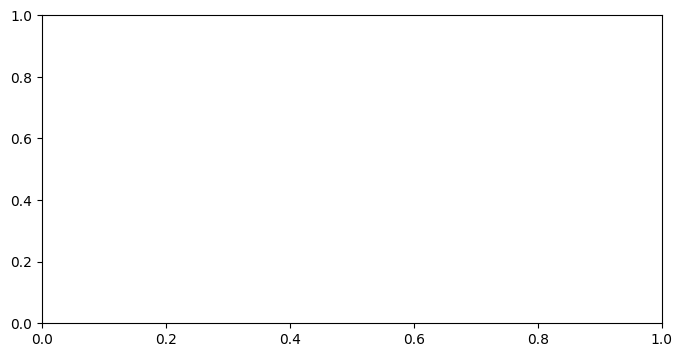

In [15]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
s = sns.scatterplot(x="turns", y="sigma_z_array",
                # palette="ch:r=-.2,d=.3_r",
                s=1, linewidth=0,
                alpha=1, data=tp, legend=False, 
                ax=ax, color='#107895')
s.set_rasterized(True)
# Customize the plot appearance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Number of turns', fontsize=16)
ax.set_ylabel('$\sigma_{z}$ [mm]', fontsize=16)
# ax.set_xlim(0,30000)
# ax.set_ylim(0,12)
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14

# Set the figure background color
# fig.patch.set_facecolor('#F7F7F7')

# Customize the axis tick labels
ax.tick_params(axis='x', which='both', direction='in', labelsize=14)
ax.tick_params(axis='y', which='both', direction='in', labelsize=14)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(3))
# plt.legend(title='Parameters', loc='best', labels=['eps', 'sig'])
# Add a legend (optional)
# legend = ax.legend(loc='upper right', fontsize=14)
plt.savefig('microwave_instability.pdf', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'tp' is not defined

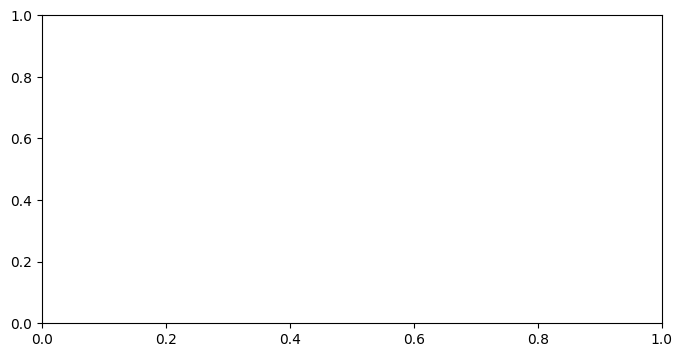

In [16]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
s = sns.scatterplot(x="turns", y="mean_x_array",
                # palette="ch:r=-.2,d=.3_r",
                s=1, linewidth=0,
                alpha=1, data=tp, legend=False, 
                ax=ax, color='#e64173')
s.set_rasterized(True)
# Customize the plot appearance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Number of turns', fontsize=16)
ax.set_ylabel('$\overline{x}$ [$\mu$m]', fontsize=16)
# ax.set_xlim(0,30000)
# ax.set_ylim(0,12)
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14

# Set the figure background color
# fig.patch.set_facecolor('#F7F7F7')
# ax.ticklabel_format(axis='both', style=None, scilimits=None, useOffset=None, useLocale=None, useMathText=None)
ax.ticklabel_format(axis='y', useMathText=True, scilimits=(0,1))
# Customize the axis tick labels
ax.tick_params(axis='x', which='both', direction='in', labelsize=14)
ax.tick_params(axis='y', which='both', direction='in', labelsize=14)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(3))
# plt.legend(title='Parameters', loc='best', labels=['eps', 'sig'])
# Add a legend (optional)
# legend = ax.legend(loc='upper right', fontsize=14)
plt.savefig('transverse.pdf', dpi=300, bbox_inches='tight')
plt.show()

## TMCI scans

### Bunch population scan - 90º injection PA31.0

In [24]:
# dir_name = '/feynman/home/ganil/ag271717/work/ag271717/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/int_scans_90deg_6e4trn'
dir_name = '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/int_scans_90deg_6e4trn'

In [17]:
# two functions to find the closest hamming number
def is_hamming_numbers(x):
	if x == 1:
		return 1
	if x % 2 == 0:
		return is_hamming_numbers(x/2)
	if x % 3 == 0:
		return is_hamming_numbers(x/3)
	if x % 5 == 0:
		return is_hamming_numbers(x/5)
	return 0

def hamming(x): # returns the closest hamming number
    x = x - 1
    while is_hamming_numbers(x) == False:
        x = x - 1
    return x

Bunch population scan - 90º injection PA31.0
Extract all data for y momenta

In [18]:
# extract a list of h5 statistics files for y momenta
list_files = []
for path, currentDirectory, files in os.walk(dir_name):
    for file in files:
        if file.startswith("y_moments"):
            list_files.append(path+'/'+file)

NameError: name 'dir_name' is not defined

In [19]:
# tests
test_file = list_files[0]
h5_file = h5py.File(test_file, 'r') 
Q_s0 = h5_file['Q_s'][()]
print('Qs_0 = ', Q_s0)
print('keys : ',h5_file.keys())
Q_frac = h5_file['Q_y'][()]
Q_frac = round(Q_frac - np.fix(Q_frac),5)
print ('Q_frac = ',Q_frac)
input_conf = os.path.dirname(os.path.dirname(os.path.dirname(test_file)))+'/input_conf.json'
f = open(input_conf)
d = json.load(f)
d['copper']


IndexError: list index out of range

In [28]:
## LOADING THE MOMENTA
intensity_array = []
momenta_matrix_array = []
#for (root,dirs,files) in os.walk('x_moments', topdown=True):   
for file_name in list_files:
#    h5_file = h5py.File('x_moments/'+file_name, 'r')
    input_conf = os.path.dirname(os.path.dirname(os.path.dirname(file_name)))+'/input_conf.json'
    f = open(input_conf)
    d = json.load(f)
    if d['wake'] == True and d['copper'] == True:
        h5_file = h5py.File(file_name, 'r')
        intensity_array.append(h5_file['n_particles'][()])
    #    momenta_matrix_array.append(h5_file['x_moments'][()])
        momenta_matrix_array.append(h5_file['y_moments'][()])
intensity_array = np.asarray(intensity_array)
momenta_matrix_array = np.asarray(momenta_matrix_array)
index_sort = np.argsort(intensity_array) 
intensity_array = intensity_array[index_sort]
momenta_matrix_array = momenta_matrix_array[index_sort] 


30769230769.0


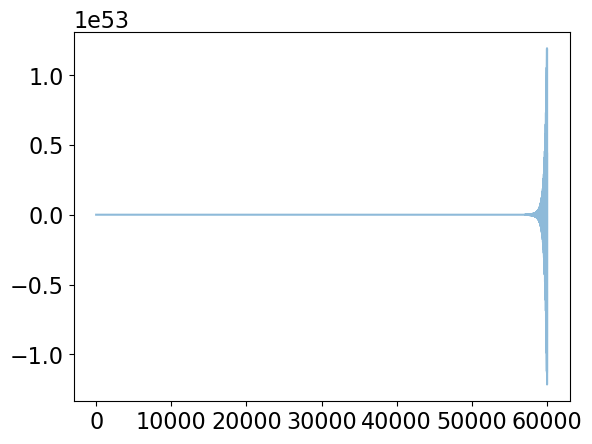

In [29]:
#%% plot one momentum as check
nfile=8
n_mom=0
moms= momenta_matrix_array[nfile,n_mom,:]
moms=np.sign(moms)*np.abs(moms)**1/float(n_mom+1)
print (intensity_array[nfile])
plt.close('all')
plt.figure()
plt.plot(moms, alpha=0.5)
plt.show()

In [20]:
#%%
## DOING THE FFTS
nturns = len(momenta_matrix_array[0][0,:])-1
n_points_fft = hamming(nturns) # it should be a Hamming number (product of only powers of 2, 3 and 5) for FFT speed up (never more than n_turn)
n_in = 0
n_fin = n_in + n_points_fft
# print('n_points_fft is a regular number: '+str(next_regular(n_points_fft)==n_points_fft))
n_file_min = 0
n_file_max = len(intensity_array)-1
#n_file_max = 20
#n_file_min = 30
#n_file_max = 40
max_ampl = 1e500 # 1e308 is finite, 1e309 is infinite
min_momentum = 0
max_momentum = 10
data_fft=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))
# data_fft2=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))

for i in range(n_file_max-n_file_min+1):
    momenta_matrix = momenta_matrix_array[i+n_file_min]
   # print ('Intensity = ', intensity_array[i+n_file_min])
    for i1 in range(min_momentum,max_momentum+1): 
        aux = np.sign(momenta_matrix[i1,n_in:n_fin])* \
                np.abs(momenta_matrix[i1,n_in:n_fin])**(1./(float(i1+1)))
        n1 = np.where((np.abs(aux)>max_ampl)|(np.isnan(aux))) 
        aux[n1] = 0
        aux1 = np.abs(np.fft.rfft(aux))
        # aux2 = np.imag(np.fft.rfft(aux))
        # aux2 = aux2/np.max(aux2)
        aux1 = aux1/np.max(aux1)
        data_fft[i,:] = data_fft[i,:] + aux1
        # data_fft2[i,:] = data_fft2[i,:] + aux2

freq = fftpack.rfftfreq(int(n_points_fft/2)+1, d=1)
x = (freq-Q_frac)/Q_s0
n_data = np.where(np.abs(x)<=1000)
x1 = x[n_data]
# print(freq)
# print(x)
# print(n_data)

NameError: name 'momenta_matrix_array' is not defined

In [21]:
#%%
from cycler import cycler
import matplotlib.style
import matplotlib as mpl
# mpl.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')
# T = Table()
plt.close('all')
### PLOT 1
#n_file_max = 3
#n_file_min = 0
# plt.figure(figsize=(8,2*(n_file_max-n_file_min+1)))
n = n_file_max-n_file_min+1
fig, axs = plt.subplots(nrows=n, ncols=1, 
                        figsize=(7,5), dpi=100,
                        subplot_kw={'xticks': [], 'yticks': []},
                        sharex=True)
plt.subplots_adjust(wspace=-0.2, hspace=0)
# axs[0].set_title('Frequency analysis as a function of bunch population')
colors = iter([plt.cm.Set2(i) for i in range(n_file_max-n_file_min+1)])
for i0 in range(n_file_max-n_file_min+1):
    # T_temp = Table()
    co = next(colors)
    # axs[i0].subplot(n_file_max-n_file_min+1,1,i0+1)
    axs[i0].tick_params(axis='both', which='both', labelsize=0, left=False)
    # plt.title('N_p = '+ str(intensity_array[i0+n_file_min]*1e-10), fontsize=10)
    y = np.abs(data_fft[i0])
    y1 = y[n_data]
    axs[i0].semilogy(x1,y1, linewidth=0.5, color=co)
    axs[i0].fill_between(x1,y1, linewidth=0.5, color=co)
    axs[i0].axhline(y=0, lw=2)
    # T_temp['x'] = x1
    # T_temp['y'] = y1
    # T_temp['Np'] = intensity_array[i0+n_file_min]
    # T = vstack([T, T_temp])
    axs[i0].set_xlim(-3,3)
    axs[i0].set_xlabel('')
    axs[i0].set_xticks([])
    # axs[i0].set_ylabel("{:.2e}".format(intensity_array[i0+n_file_min]), 
                    #    fontsize=10, rotation='horizontal', color=co)
    axs[i0].text(-4,min(y1),"{:.2e}".format(intensity_array[i0+n_file_min]), color=co)
    axs[i0].yaxis.labelpad = -100
    axs[i0].yaxis.set_label_coords(-.15, .1)
    # axs[i0].set_ylabel('')
    axs[i0].set_yticks([])
    axs[i0].spines['right'].set_visible(False)
    axs[i0].spines['top'].set_visible(False)
    axs[i0].spines['bottom'].set_visible(False)
    axs[i0].spines['left'].set_visible(False)
    # axs[i0].ticklabel_format(axis='y', useMathText=True, scilimits=(0,1))
    # axs[i0].yaxis.set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
# plt.tight_layout()
plt.savefig('fft_inj90.pdf', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'n_file_max' is not defined

NameError: name 'n_data' is not defined

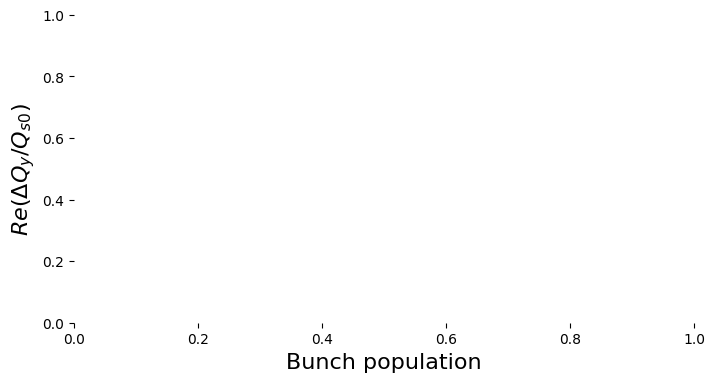

In [22]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('Bunch population', fontsize=16)
ax.set_ylabel('$Re(\Delta Q_{y}/Q_{s0})$', fontsize=16)
plt.rc('xtick', labelsize=16)# Set the font size for x tick labels
plt.rc('ytick', labelsize=16)# Set the font size for y tick labels
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14
#
Z_fft=np.zeros((len(n_data[0]), n_file_max-n_file_min+1))
for i0 in range(n_file_max-n_file_min+1):
    y = data_fft[i0]
    y = np.where(y==0, 1e-20, y)
    y = np.log10(y)
    Z_fft[:,i0] = y[n_data]
#
ax.imshow(Z_fft, origin='lower', interpolation='spline36', #vmin=-1., vmax=0.5,
	extent=[intensity_array[n_file_min], intensity_array[n_file_max], x1.min(), x1.max()], 
         cmap='nipy_spectral', aspect=6e9)
ax.set_ylim(-3,3)
ax.axvline(2.43e10, color='white', linestyle='--')
ax.text(2.2e10, -2.7, 'Nominal', rotation='vertical', color='white')
plt.savefig('tmci_pa310_90.pdf', dpi=400, bbox_inches='tight')
plt.show()

In [23]:
## PLOT 2
#%%
plt.close()

# definisce la dimensione dei caratteri degli assi globalmente
# così non serve sotto plt.tick_params ...
plt.rc('font', size=14)# Set the default text font size
plt.rc('axes', titlesize=16)# Set the axes title font size
plt.rc('axes', labelsize=16)# Set the axes labels font size
plt.rc('xtick', labelsize=16)# Set the font size for x tick labels
plt.rc('ytick', labelsize=16)# Set the font size for y tick labels
plt.rc('legend', fontsize=14)# Set the legend font size
plt.rc('figure', titlesize=16)# Set the font size of the figure title

Z_fft=np.zeros((len(n_data[0]), n_file_max-n_file_min+1))
for i0 in range(n_file_max-n_file_min+1):
    y = data_fft[i0]
    y = np.where(y==0, 1e-20, y)
    y = np.log10(y)
    Z_fft[:,i0] = y[n_data]
    
plt.figure(figsize=(10,7))
plt.imshow(Z_fft, origin='lower', interpolation='spline36', #vmin=-1., vmax=0.5,
	extent=[intensity_array[n_file_min], intensity_array[n_file_max], x1.min(), x1.max()], 
         cmap='jet', aspect=3e9)
# plt.grid('on')
# plt.xlim(0, 24e10)
plt.ylim(-3, 3)
plt.xlabel('$N_p$', fontsize=18)
plt.ylabel('$Re(\Delta Q_{y}/Q_{s0})$', fontsize=18)
# if compare_with_DELPHI:
#     directory = '../PyDELPHI_simulations/simulation_results/test2'
#     tuneshiftnx = np.load(directory+'/tuneshiftnx.npy', allow_pickle=True)
#     other_params = h5py.File(directory+'/other_params.h5', 'r')
#     Nbscan = other_params['Nbscan'][()]
#     omega0 = other_params['omega0'][()]
#     omegas = other_params['omegas'][()]
#     for iNb, Nb in enumerate(Nbscan):
#         plt.plot(Nb*np.ones(len(tuneshiftnx[iNb])),
#                  np.real(tuneshiftnx[iNb])*omega0/omegas, marker='o', color='g',
#                  markersize=10, linestyle="None")
# for i in intensity_array:
#     plt.axvline(i, linestyle='--', color='red', linewidth=0.5)
plt.axvline(2.49e10, linestyle='--', color='red', linewidth=2)
plt.subplots_adjust(left=0.14, right=0.96, bottom=0.12, top=0.96)
plt.savefig('tmci_90.pdf', dpi=400, bbox_inches='tight')
plt.show()

NameError: name 'n_data' is not defined

### Momentum compaction scans

In [34]:
dir_name = '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/inj90_scan_alpha'

In [35]:
# extract a list of h5 statistics files for y momenta
list_files = []
for path, currentDirectory, files in os.walk(dir_name):
    for file in files:
        if file.startswith("y_moments"):
            list_files.append(path+'/'+file)

In [36]:
# tests
test_file = list_files[0]
h5_file = h5py.File(test_file, 'r') 
Q_s0 = h5_file['Q_s'][()]
print('Qs_0 = ', Q_s0)
print('keys : ',h5_file.keys())
Q_frac = h5_file['Q_y'][()]
Q_frac = round(Q_frac - np.fix(Q_frac),5)
print ('Q_frac = ',Q_frac)
input_conf = os.path.dirname(os.path.dirname(os.path.dirname(test_file)))+'/input_conf.json'
f = open(input_conf)
d = json.load(f)
d['copper']


Qs_0 =  0.0335567356367324
keys :  <KeysViewHDF5 ['Q_s', 'Q_y', 'n_particles', 'y_moments']>
Q_frac =  0.29


True

In [37]:
#%%
# OTHER PARAMETERS
compare_with_DELPHI = False

In [38]:
# loading momenta and alpha array
alpha_array = []
momenta_matrix_array = []
# file_name = list_files[0]
for file_name in list_files:
    input_conf = os.path.dirname(os.path.dirname(os.path.dirname(file_name)))+'/input_conf.json'
    f = open(input_conf)
    d = json.load(f)
    alpha_array.append(d['alpha'])
    h5_file = h5py.File(file_name, 'r')
    momenta_matrix_array.append(h5_file['y_moments'][()])
alpha_array = np.asarray(alpha_array)
momenta_matrix_array = np.asarray(momenta_matrix_array)
index_sort = np.argsort(alpha_array) 
alpha_array = alpha_array[index_sort]
momenta_matrix_array = momenta_matrix_array[index_sort]


alpha  6.116666666666666e-06


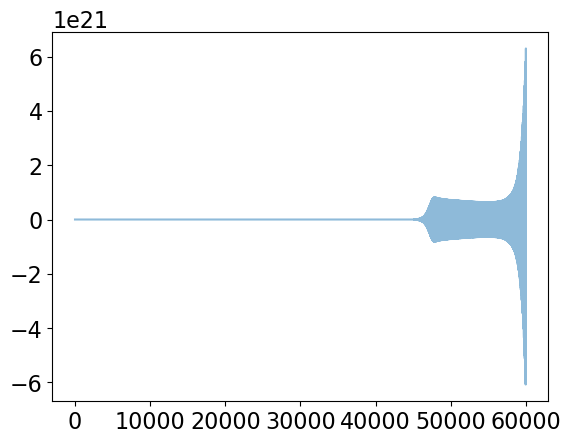

In [39]:
#%% plot one momentum as check
nfile=1
n_mom=0
moms= momenta_matrix_array[nfile,n_mom,:]
moms=np.sign(moms)*np.abs(moms)**1/float(n_mom+1)
print('alpha ', alpha_array[nfile])
plt.close('all')
plt.figure()
plt.plot(moms, alpha=0.5)
plt.show()

In [40]:
#%%
## DOING THE FFTS
nturns = len(momenta_matrix_array[0][0,:])-1
n_points_fft = hamming(nturns) # it should be a Hamming number (product of only powers of 2, 3 and 5) for FFT speed up (never more than n_turn)
n_in = 0
n_fin = n_in + n_points_fft
# print('n_points_fft is a regular number: '+str(next_regular(n_points_fft)==n_points_fft))
n_file_min = 0
n_file_max = len(alpha_array)-1
#n_file_max = 20
#n_file_min = 30
#n_file_max = 40
max_ampl = 1e500 # 1e308 is finite, 1e309 is infinite
min_momentum = 0
max_momentum = 10
data_fft=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))
# data_fft2=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))

for i in range(n_file_max-n_file_min+1):
    momenta_matrix = momenta_matrix_array[i+n_file_min]
   # print ('Intensity = ', intensity_array[i+n_file_min])
    for i1 in range(min_momentum,max_momentum+1): 
        aux = np.sign(momenta_matrix[i1,n_in:n_fin])* \
                np.abs(momenta_matrix[i1,n_in:n_fin])**(1./(float(i1+1)))
        n1 = np.where((np.abs(aux)>max_ampl)|(np.isnan(aux))) 
        aux[n1] = 0
        aux1 = np.abs(np.fft.rfft(aux))
        # aux2 = np.imag(np.fft.rfft(aux))
        # aux2 = aux2/np.max(aux2)
        aux1 = aux1/np.max(aux1)
        data_fft[i,:] = data_fft[i,:] + aux1
        # data_fft2[i,:] = data_fft2[i,:] + aux2

freq = fftpack.rfftfreq(int(n_points_fft/2)+1, d=1)
x = (freq-Q_frac)/Q_s0
n_data = np.where(np.abs(x)<=1000)
x1 = x[n_data]
# print(freq)
# print(x)
# print(n_data)

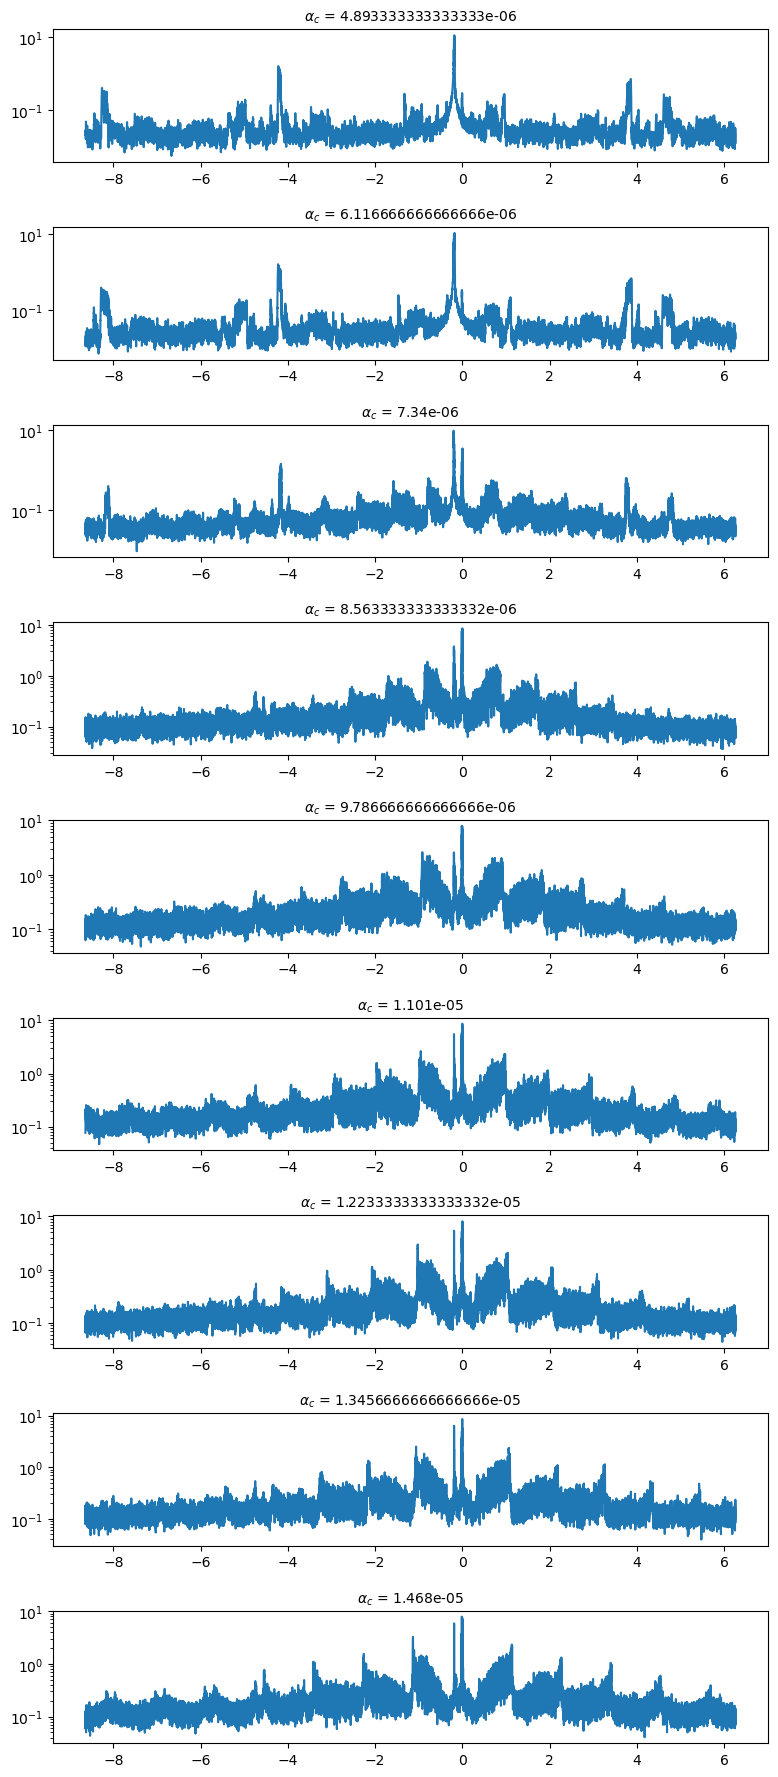

In [41]:
#%%
plt.close('all')
### PLOT 1
#n_file_max = 3
#n_file_min = 0
plt.figure(figsize=(8,2*(n_file_max-n_file_min+1)))
for i0 in range(n_file_max-n_file_min+1):
    plt.subplot(n_file_max-n_file_min+1,1,i0+1)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.title(r'$\alpha_c$ = '+ str(alpha_array[i0+n_file_min]), fontsize=10)
    y = np.abs(data_fft[i0])
    y1 = y[n_data]
    plt.semilogy(x1,y1)
plt.tight_layout()
plt.show()

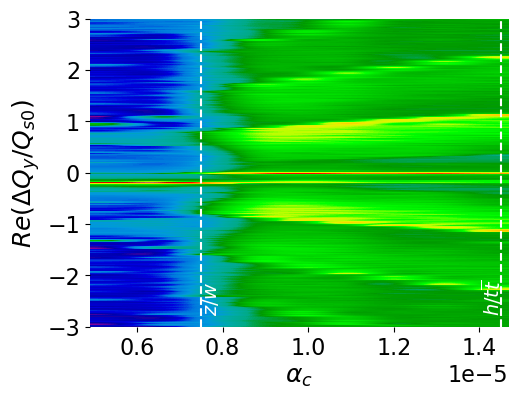

In [42]:
## PLOT 2
#%%
plt.close()
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('Bunch population', fontsize=16)
ax.set_ylabel('$Re(\Delta Q_{y}/Q_{s0})$', fontsize=16)
plt.rc('xtick', labelsize=16)# Set the font size for x tick labels
plt.rc('ytick', labelsize=16)# Set the font size for y tick labels
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14


Z_fft=np.zeros((len(n_data[0]), n_file_max-n_file_min+1))
for i0 in range(n_file_max-n_file_min+1):
    y = data_fft[i0]
    y = np.where(y==0, 1e-20, y)
    y = np.log10(y)
    Z_fft[:,i0] = y[n_data]
    
ax.imshow(Z_fft, origin='lower', interpolation='spline36',# vmin=2, vmax=2,
	extent=[alpha_array[n_file_min], alpha_array[n_file_max], x1.min(), x1.max()], 
         cmap='nipy_spectral', aspect=12e-7)
# plt.grid('off')
# plt.xlim(0, 24e10)
ax.set_ylim(-3, 3)
ax.set_xlabel(r'$\alpha_c$', fontsize=18)
ax.set_ylabel('$Re(\Delta Q_{y}/Q_{s0})$', fontsize=18)
# for i in alpha_array:
#     plt.axvline(i, linestyle='--', color='red', linewidth=0.5)
# ax.axvline(14.9e-5, linestyle='--', color='white', linewidth=1)
ax.axvline(7.5e-6, linestyle='--', color='white')
ax.axvline(14.5e-6, linestyle='--', color='white')
ax.text(7.5e-6, -2.7, '$z/w$', rotation='vertical', color='white')
ax.text(14e-6, -2.7, '$h/t\overline{t}$', rotation='vertical', color='white')
# plt.subplots_adjust(left=0.14, right=0.96, bottom=0.12, top=0.96)
plt.savefig('tmci_alpha.pdf', dpi=300, bbox_inches='tight')
plt.show()

### Beam pipe radius scan

In [4]:
dir_name = '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/inj90_scan_r'

In [5]:
# extract a list of h5 statistics files for y momenta
list_files = []
for path, currentDirectory, files in os.walk(dir_name):
    for file in files:
        if file.startswith("x_moments"):
            list_files.append(path+'/'+file)

In [6]:
# tests
test_file = list_files[0]
h5_file = h5py.File(test_file, 'r') 
Q_s0 = h5_file['Q_s'][()]
print('Qs_0 = ', Q_s0)
print('keys : ',h5_file.keys())
Q_frac = h5_file['Q_x'][()]
Q_frac = round(Q_frac - np.fix(Q_frac),5)
print ('Q_frac = ',Q_frac)
input_conf = os.path.dirname(os.path.dirname(os.path.dirname(test_file)))+'/input_conf.json'
f = open(input_conf)
d = json.load(f)
d['copper']


Qs_0 =  0.02733796112738744
keys :  <KeysViewHDF5 ['Q_s', 'Q_x', 'n_particles', 'x_moments']>
Q_frac =  0.225


False

In [7]:
# loading momenta and alpha array
r_pipe_array = []
momenta_matrix_array = []
# file_name = list_files[0]
for file_name in list_files:
    input_conf = os.path.dirname(os.path.dirname(os.path.dirname(file_name)))+'/input_conf.json'
    f = open(input_conf)
    d = json.load(f)
    r_pipe_array.append(d['r_pipe'])
    h5_file = h5py.File(file_name, 'r')
    momenta_matrix_array.append(h5_file['x_moments'][()])
r_pipe_array = np.asarray(r_pipe_array)
momenta_matrix_array = np.asarray(momenta_matrix_array)
index_sort = np.argsort(r_pipe_array) 
r_pipe_array = r_pipe_array[index_sort]
momenta_matrix_array = momenta_matrix_array[index_sort]


In [8]:
# tests
test_file = list_files[0]
h5_file = h5py.File(test_file, 'r') 
Q_s0 = h5_file['Q_s'][()]
print('Qs_0 = ', Q_s0)
print('keys : ',h5_file.keys())
Q_frac = h5_file['Q_x'][()]
Q_frac = round(Q_frac - np.fix(Q_frac),5)
print ('Q_frac = ',Q_frac)
input_conf = os.path.dirname(os.path.dirname(os.path.dirname(test_file)))+'/input_conf.json'
f = open(input_conf)
d = json.load(f)
d['copper']


Qs_0 =  0.02733796112738744
keys :  <KeysViewHDF5 ['Q_s', 'Q_x', 'n_particles', 'x_moments']>
Q_frac =  0.225


False

r_pipe  0.030555555555555558


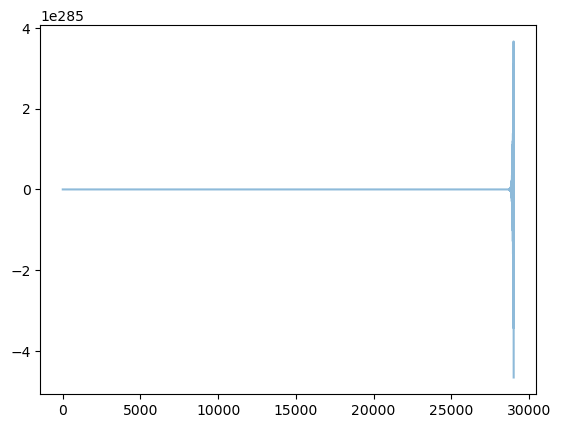

In [9]:
#%% plot one momentum as check
nfile=1
n_mom=0
moms= momenta_matrix_array[nfile,n_mom,:]
moms=np.sign(moms)*np.abs(moms)**1/float(n_mom+1)
print('r_pipe ', r_pipe_array[nfile])
plt.close('all')
plt.figure()
plt.plot(moms, alpha=0.5)
plt.show()

In [10]:
#%%
## DOING THE FFTS
nturns = len(momenta_matrix_array[0][0,:])-1
n_points_fft = hamming(nturns) # it should be a Hamming number (product of only powers of 2, 3 and 5) for FFT speed up (never more than n_turn)
n_in = 0
n_fin = n_in + n_points_fft
# print('n_points_fft is a regular number: '+str(next_regular(n_points_fft)==n_points_fft))
n_file_min = 0
n_file_max = len(r_pipe_array)-1
#n_file_max = 20
#n_file_min = 30
#n_file_max = 40
max_ampl = 1e500 # 1e308 is finite, 1e309 is infinite
min_momentum = 0
max_momentum = 10
data_fft=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))
# data_fft2=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))

for i in range(n_file_max-n_file_min+1):
    momenta_matrix = momenta_matrix_array[i+n_file_min]
   # print ('Intensity = ', intensity_array[i+n_file_min])
    for i1 in range(min_momentum,max_momentum+1): 
        aux = np.sign(momenta_matrix[i1,n_in:n_fin])* \
                np.abs(momenta_matrix[i1,n_in:n_fin])**(1./(float(i1+1)))
        n1 = np.where((np.abs(aux)>max_ampl)|(np.isnan(aux))) 
        aux[n1] = 0
        aux1 = np.abs(np.fft.rfft(aux))
        # aux2 = np.imag(np.fft.rfft(aux))
        # aux2 = aux2/np.max(aux2)
        aux1 = aux1/np.max(aux1)
        data_fft[i,:] = data_fft[i,:] + aux1
        # data_fft2[i,:] = data_fft2[i,:] + aux2

freq = fftpack.rfftfreq(int(n_points_fft/2)+1, d=1)
x = (freq-Q_frac)/Q_s0
n_data = np.where(np.abs(x)<=1000)
x1 = x[n_data]
# print(freq)
# print(x)
# print(n_data)

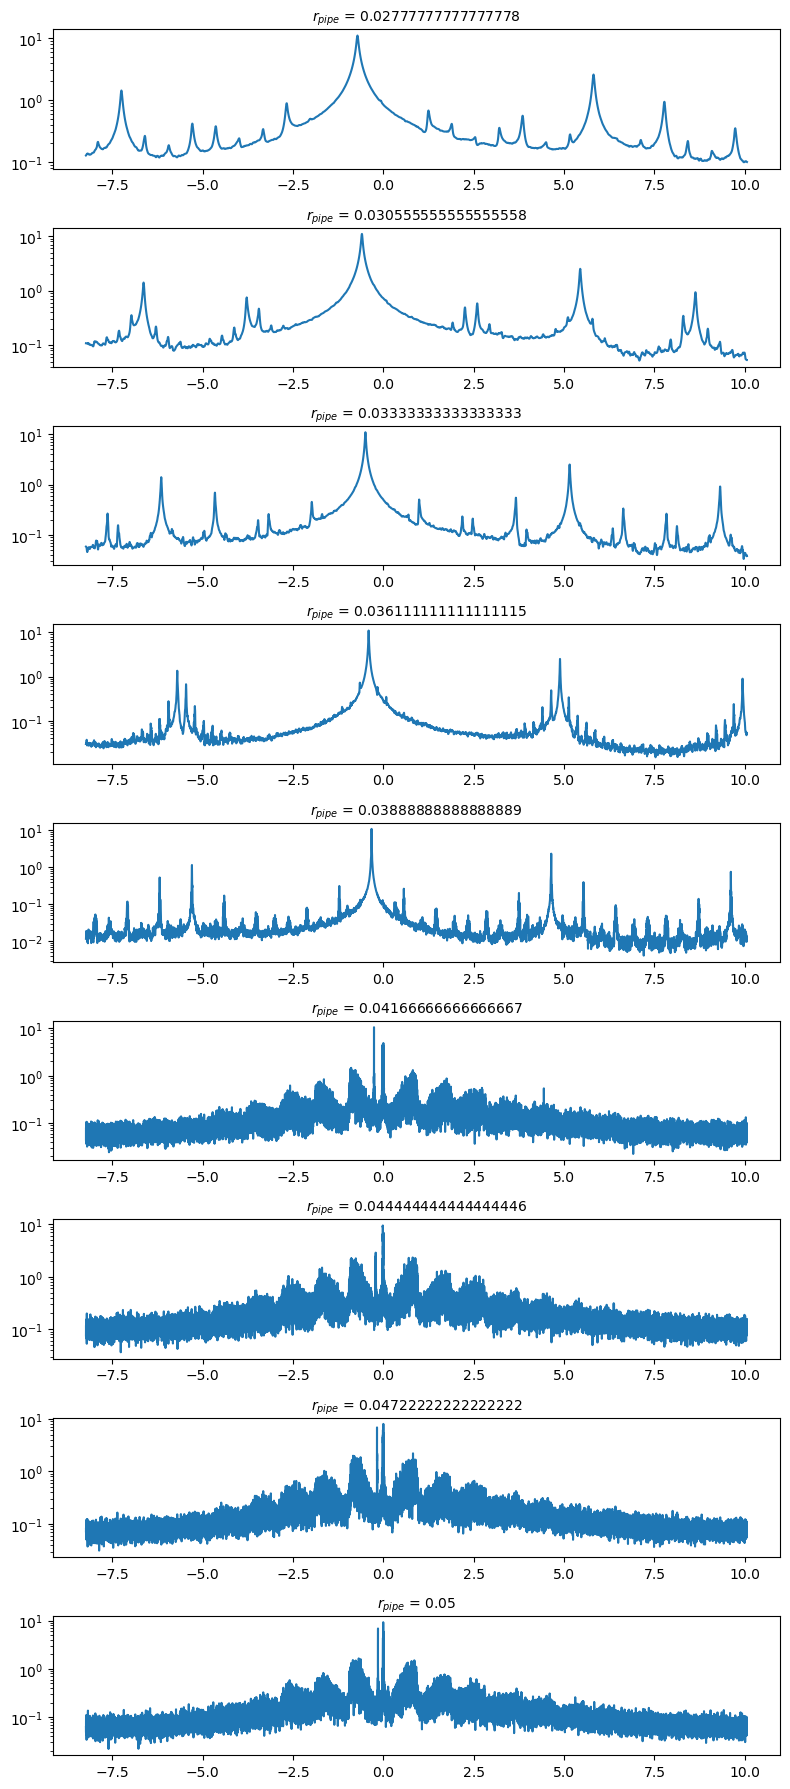

In [11]:
#%%
plt.close('all')
### PLOT 1
#n_file_max = 3
#n_file_min = 0
plt.figure(figsize=(8,2*(n_file_max-n_file_min+1)))
for i0 in range(n_file_max-n_file_min+1):
    plt.subplot(n_file_max-n_file_min+1,1,i0+1)
    plt.tick_params(axis='both', which='major', labelsize=10)
    plt.title(r'$r_{pipe}$ = '+ str(r_pipe_array[i0+n_file_min]), fontsize=10)
    y = np.abs(data_fft[i0])
    y1 = y[n_data]
    plt.semilogy(x1,y1)
plt.tight_layout()
plt.show()

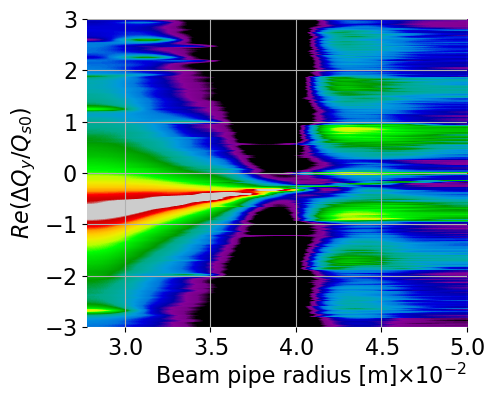

In [20]:
## PLOT 2
#%%
plt.close()
plt.close()
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('Beam pipe radius [m]', fontsize=16)
ax.set_ylabel('$Re(\Delta Q_{y}/Q_{s0})$', fontsize=16)
plt.rc('xtick', labelsize=16)# Set the font size for x tick labels
plt.rc('ytick', labelsize=16)# Set the font size for y tick labels
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14
plt.rc('xtick',labelsize=16)
plt.rc('ytick',labelsize=16)

Z_fft=np.zeros((len(n_data[0]), n_file_max-n_file_min+1))
for i0 in range(n_file_max-n_file_min+1):
    y = data_fft[i0]
    y = np.where(y==0, 1e-20, y)
    y = np.log10(y)
    Z_fft[:,i0] = y[n_data]
    
# plt.figure(figsize=(10,7))
ax.imshow(Z_fft, origin='lower', interpolation='spline36', vmin=-1., vmax=0.5,
	extent=[r_pipe_array[n_file_min], r_pipe_array[n_file_max], x1.min(), x1.max()], 
         cmap='nipy_spectral', aspect='3e-3')
ax.grid('on')
# plt.xlim(0, 24e10)
plt.ylim(-3, 3)
# ax.set_xlabel(r'$r_{pipe}$ [m]', fontsize=18)
# ax.set_ylabel('$Re(\Delta Q_{x}/Q_{s0})$', fontsize=18)
ax.ticklabel_format(axis='both', 
    style='scientific', scilimits=(-1,2), useOffset=None, 
    useLocale=None, useMathText=True)
# for i in alpha_array:
#     plt.axvline(i, linestyle='--', color='red', linewidth=0.5)
# plt.subplots_adjust(left=0.14, right=0.96, bottom=0.12, top=0.96)
plt.savefig('rpipe_scan.pdf', dpi=100, bbox_inches='tight')
plt.show()

### SS vs Copper

In [8]:
dir_name = '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/result_local/2023_04_11'

In [9]:
list_files = []
for path, currentDirectory, files in os.walk(dir_name):
    for file in files:
        if file.startswith("statistics_and_parameters.h5"):
            list_files.append(path+'/'+file)

In [10]:
filename = list_files[0]
f = h5py.File(filename, "r")
f.keys()
t1 = extract3_(filename)
t1

mean_x_array,sigma_z_array,alpha,n_turns,epsn_y_array,sigma_z,sigma_dp_array,epsn_y,turns
float64,float64,float64,int64,float64,float64,float64,float64,int64
-0.09776507982417179,0.9997881724736652,7.34e-06,45000,10.014202783236989,1.0,0.1000616031924741,10.014202783236989,0
-0.050311266918622276,1.188127837574691,7.34e-06,45000,10.01353949021508,1.0,0.11865650981691249,10.014202783236989,1
0.06494855737782511,1.7940023736257178,7.34e-06,45000,10.012876496141534,1.0,0.13062380695741774,10.014202783236989,2
0.075094029817881,2.5665095070032757,7.34e-06,45000,10.012216402896625,1.0,0.13298705787383464,10.014202783236989,3
-0.035755361392640836,3.3752791521574417,7.34e-06,45000,10.011559691416858,1.0,0.12810440066436635,10.014202783236989,4
-0.09026823429438972,4.152255681411917,7.34e-06,45000,10.010888713659954,1.0,0.11762170705381142,10.014202783236989,5
0.002305064652292282,4.853608099137792,7.34e-06,45000,10.010230030087763,1.0,0.10274967422939382,10.014202783236989,6
0.09421155468358408,5.447680592155042,7.34e-06,45000,10.009577316432367,1.0,0.08392679070328944,10.014202783236989,7
0.03254515615595374,5.907069825304988,7.34e-06,45000,10.008918054815624,1.0,0.06223238927704149,10.014202783236989,8


In [11]:
# loading and stacking tables parameters
t = load_t2(list_files)
tp = t.to_pandas() # to pandas
# tp # check structure

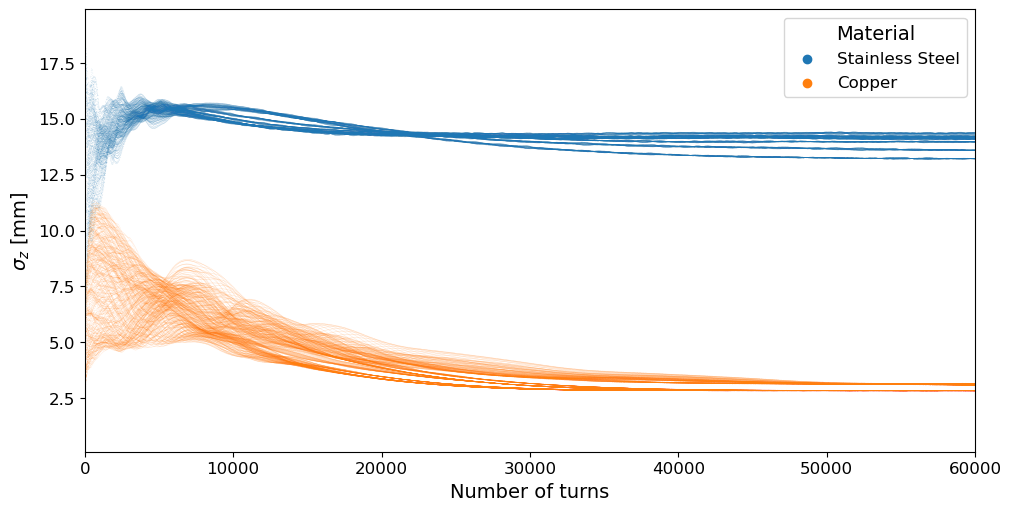

In [12]:
plt.rc('font', size=14)# Set the default text font size
plt.rc('axes', titlesize=16)# Set the axes title font size
plt.rc('axes', labelsize=14)# Set the axes labels font size
plt.rc('xtick', labelsize=12)# Set the font size for x tick labels
plt.rc('ytick', labelsize=12)# Set the font size for y tick labels
plt.rc('legend', fontsize=12)# Set the legend font size
plt.rc('figure', titlesize=16)# Set the font size of the figure title

fig, axs = plt.subplots(figsize=(10, 5), layout='constrained', sharex=True)
axs.set_xlabel('Number of turns')
axs.set_ylabel(r'$\sigma_z$ [mm]')
sns.scatterplot(x="turns", y="sigma_z_array",
                hue="Material", 
                # size="sigma_z",
                # palette="deep",
                # hue_order="epsn_y",
                s=0.2, linewidth=0,
                alpha=0.2, 
                data=tp, 
                ax=axs, 
                legend=True,
                rasterized=True)
axs.set_xlim(min(tp.turns), max(tp.turns))
fig.savefig('copper_vs_ss.png', dpi=400)
plt.show()

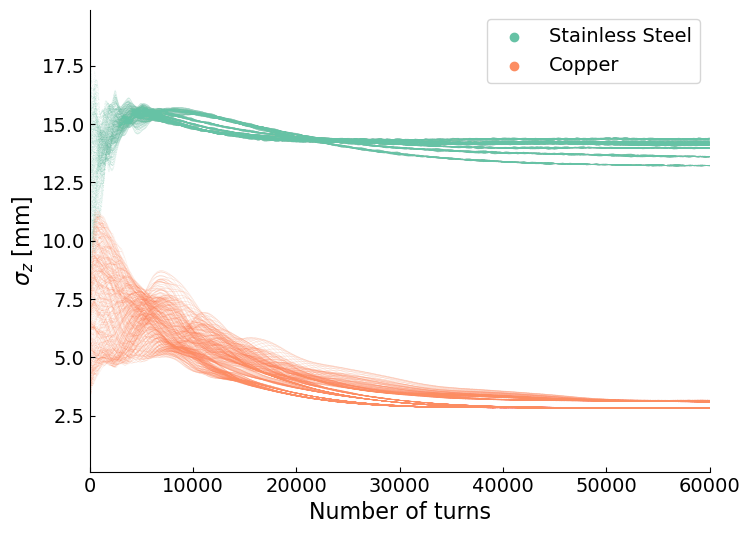

In [16]:
fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
sns.scatterplot(x="turns", y="sigma_z_array",
                hue="Material", 
                s=0.2, linewidth=0,
                alpha=0.2, 
                data=tp, 
                ax=ax, 
                legend=True,
                rasterized=True,
                palette='Set2')
# Customize the plot appearance
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_xlabel('Number of turns', fontsize=16)
ax.set_ylabel('$\sigma_{z}$ [mm]', fontsize=16)
ax.set_xlim(0,60000)
# ax.set_ylim(0,12)
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14

# Set the figure background color
# fig.patch.set_facecolor('#F7F7F7')

# Customize the axis tick labels
ax.tick_params(axis='x', which='both', direction='in', labelsize=14)
ax.tick_params(axis='y', which='both', direction='in', labelsize=14)
# ax.xaxis.set_major_locator(ticker.MultipleLocator(3))
# plt.legend(title='Parameters', loc='best', labels=['eps', 'sig'])
# Add a legend (optional)
legend = ax.legend(loc='upper right', fontsize=14)
plt.savefig('copper_vs_ss.pdf', dpi=100, bbox_inches='tight')
plt.show()

### Updated booster parameters

In [9]:
dir_name = '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/20240528_i_scan_mode_z_swake_1.0'

In [10]:
# extract a list of h5 statistics files for y momenta
list_files = []
for path, currentDirectory, files in os.walk(dir_name):
    for file in files:
        if file.startswith("y_moments"):
            list_files.append(path+'/'+file)

In [11]:
list_files

['/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/20240528_i_scan_mode_z_swake_1.0/np_0_00012316964221320537/data/moments/y_moments0.00012316964221320537.h5',
 '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/20240528_i_scan_mode_z_swake_1.0/np_0_0004671442938180244/data/moments/y_moments0.00046714429381802434.h5',
 '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/20240528_i_scan_mode_z_swake_1.0/np_0_0017717335808201669/data/moments/y_moments0.0017717335808201666.h5',
 '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/20240528_i_scan_mode_z_swake_1.0/np_0_006719636572567576/data/moments/y_moments0.006719636572567576.h5',
 '/eos/project/f/fcc-ee-ce/Adnan/_d

In [12]:
# tests
test_file = list_files[0]
h5_file = h5py.File(test_file, 'r') 
Q_s0 = h5_file['Q_s'][()]
print('Qs_0 = ', Q_s0)
print('keys : ',h5_file.keys())
Q_frac = h5_file['Q_y'][()]
Q_frac = round(Q_frac - np.fix(Q_frac),5)
print ('Q_frac = ',Q_frac)
input_conf = os.path.dirname(os.path.dirname(os.path.dirname(test_file)))+'/input_conf.json'
f = open(input_conf)
d = json.load(f)
# d['copper']
d


Qs_0 =  0.02619645279140127
keys :  <KeysViewHDF5 ['Q_s', 'Q_y', 'n_particles', 'y_moments']>
Q_frac =  0.29


{'n_particles': 1231696.4221320536,
 'wake': True,
 'n_turns': 60000,
 'frequency': 800000000.0,
 'mode': 'z',
 'scale_wake': 1.0,
 'dir_name': '20240528_i_scan_mode_z_swake_1.0/np_0_00012316964221320537',
 'comp': 'feynman'}

In [24]:
## LOADING THE MOMENTA
intensity_array = []
momenta_matrix_array = []
#for (root,dirs,files) in os.walk('x_moments', topdown=True):   
for file_name in list_files:
#    h5_file = h5py.File('x_moments/'+file_name, 'r')
    input_conf = os.path.dirname(os.path.dirname(os.path.dirname(file_name)))+'/input_conf.json'
    f = open(input_conf)
    d = json.load(f)
    if d['wake'] == True:
        h5_file = h5py.File(file_name, 'r')
        intensity_array.append(h5_file['n_particles'][()])
    #    momenta_matrix_array.append(h5_file['x_moments'][()])
        momenta_matrix_array.append(h5_file['y_moments'][()])
intensity_array = np.asarray(intensity_array)
momenta_matrix_array = np.asarray(momenta_matrix_array)
index_sort = np.argsort(intensity_array) 
intensity_array = intensity_array[index_sort]
momenta_matrix_array = momenta_matrix_array[index_sort] 


In [25]:
intensity_array

array([], dtype=float64)

In [26]:
#%% plot one momentum as check
nfile=1
n_mom=0
moms= momenta_matrix_array[nfile,n_mom,:]
moms=np.sign(moms)*np.abs(moms)**1/float(n_mom+1)
print (intensity_array[nfile])
plt.close('all')
plt.figure()
plt.plot(moms, alpha=0.5)
plt.show()

IndexError: too many indices for array: array is 1-dimensional, but 3 were indexed

In [16]:
#%%
## DOING THE FFTS
nturns = len(momenta_matrix_array[0][0,:])-1
n_points_fft = hamming(nturns) # it should be a Hamming number (product of only powers of 2, 3 and 5) for FFT speed up (never more than n_turn)
n_in = 0
n_fin = n_in + n_points_fft
# print('n_points_fft is a regular number: '+str(next_regular(n_points_fft)==n_points_fft))
n_file_min = 0
n_file_max = len(intensity_array)-1
#n_file_max = 20
#n_file_min = 30
#n_file_max = 40
max_ampl = 1e500 # 1e308 is finite, 1e309 is infinite
min_momentum = 0
max_momentum = 10
data_fft=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))
# data_fft2=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))

for i in range(n_file_max-n_file_min+1):
    momenta_matrix = momenta_matrix_array[i+n_file_min]
   # print ('Intensity = ', intensity_array[i+n_file_min])
    for i1 in range(min_momentum,max_momentum+1): 
        aux = np.sign(momenta_matrix[i1,n_in:n_fin])* \
                np.abs(momenta_matrix[i1,n_in:n_fin])**(1./(float(i1+1)))
        n1 = np.where((np.abs(aux)>max_ampl)|(np.isnan(aux))) 
        aux[n1] = 0
        aux1 = np.abs(np.fft.rfft(aux))
        # aux2 = np.imag(np.fft.rfft(aux))
        # aux2 = aux2/np.max(aux2)
        aux1 = aux1/np.max(aux1)
        data_fft[i,:] = data_fft[i,:] + aux1
        # data_fft2[i,:] = data_fft2[i,:] + aux2

freq = fftpack.rfftfreq(int(n_points_fft/2)+1, d=1)
x = (freq-Q_frac)/Q_s0
n_data = np.where(np.abs(x)<=1000)
x1 = x[n_data]
# print(freq)
# print(x)
# print(n_data)

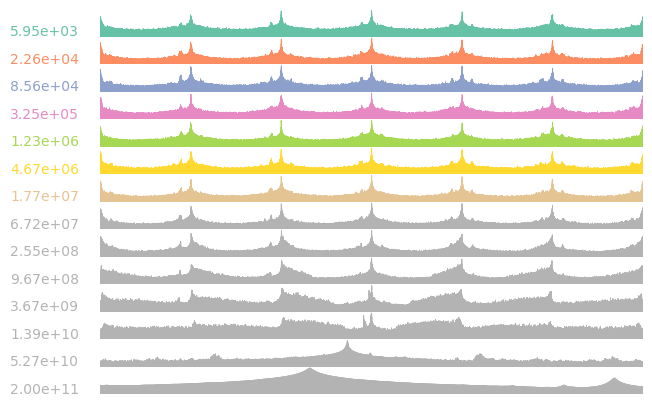

In [17]:
#%%
from cycler import cycler
import matplotlib.style
import matplotlib as mpl
# mpl.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')
# T = Table()
plt.close('all')
### PLOT 1
#n_file_max = 3
#n_file_min = 0
# plt.figure(figsize=(8,2*(n_file_max-n_file_min+1)))
n = n_file_max-n_file_min+1
fig, axs = plt.subplots(nrows=n, ncols=1, 
                        figsize=(7,5), dpi=100,
                        subplot_kw={'xticks': [], 'yticks': []},
                        sharex=True)
plt.subplots_adjust(wspace=-0.2, hspace=0)
# axs[0].set_title('Frequency analysis as a function of bunch population')
colors = iter([plt.cm.Set2(i) for i in range(n_file_max-n_file_min+1)])
for i0 in range(n_file_max-n_file_min+1):
    # T_temp = Table()
    co = next(colors)
    # axs[i0].subplot(n_file_max-n_file_min+1,1,i0+1)
    axs[i0].tick_params(axis='both', which='both', labelsize=0, left=False)
    # plt.title('N_p = '+ str(intensity_array[i0+n_file_min]*1e-10), fontsize=10)
    y = np.abs(data_fft[i0])
    y1 = y[n_data]
    axs[i0].semilogy(x1,y1, linewidth=0.5, color=co)
    axs[i0].fill_between(x1,y1, linewidth=0.5, color=co)
    axs[i0].axhline(y=0, lw=2)
    # T_temp['x'] = x1
    # T_temp['y'] = y1
    # T_temp['Np'] = intensity_array[i0+n_file_min]
    # T = vstack([T, T_temp])
    axs[i0].set_xlim(-3,3)
    axs[i0].set_xlabel('')
    axs[i0].set_xticks([])
    # axs[i0].set_ylabel("{:.2e}".format(intensity_array[i0+n_file_min]), 
                    #    fontsize=10, rotation='horizontal', color=co)
    axs[i0].text(-4,min(y1),"{:.2e}".format(intensity_array[i0+n_file_min]), color=co)
    axs[i0].yaxis.labelpad = -100
    axs[i0].yaxis.set_label_coords(-.15, .1)
    # axs[i0].set_ylabel('')
    axs[i0].set_yticks([])
    axs[i0].spines['right'].set_visible(False)
    axs[i0].spines['top'].set_visible(False)
    axs[i0].spines['bottom'].set_visible(False)
    axs[i0].spines['left'].set_visible(False)
    # axs[i0].ticklabel_format(axis='y', useMathText=True, scilimits=(0,1))
    # axs[i0].yaxis.set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
# plt.tight_layout()
# plt.savefig('fft_inj90.pdf', dpi=300, bbox_inches='tight')
plt.show()

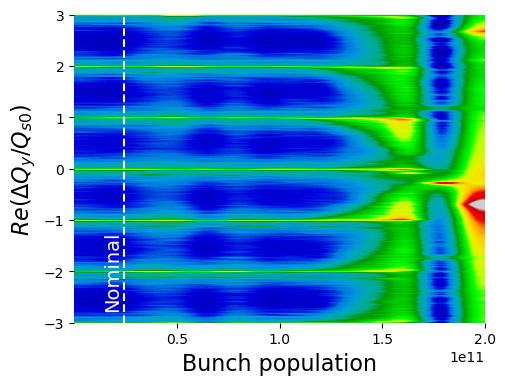

In [18]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('Bunch population', fontsize=16)
ax.set_ylabel('$Re(\Delta Q_{y}/Q_{s0})$', fontsize=16)
plt.rc('xtick', labelsize=16)# Set the font size for x tick labels
plt.rc('ytick', labelsize=16)# Set the font size for y tick labels
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14
#
Z_fft=np.zeros((len(n_data[0]), n_file_max-n_file_min+1))
for i0 in range(n_file_max-n_file_min+1):
    y = data_fft[i0]
    y = np.where(y==0, 1e-20, y)
    y = np.log10(y)
    Z_fft[:,i0] = y[n_data]
#
ax.imshow(Z_fft, origin='lower', interpolation='spline36', #vmin=-1., vmax=0.5,
	extent=[intensity_array[n_file_min], intensity_array[n_file_max], x1.min(), x1.max()], 
         cmap='nipy_spectral', aspect=25e9)
# ax.grid('on')
ax.set_ylim(-3,3)
ax.axvline(2.43e10, color='white', linestyle='--')
ax.text(1.4e10, -2.7, 'Nominal', rotation='vertical', color='white')
plt.savefig('tmci_pa313.pdf', dpi=400, bbox_inches='tight')
plt.show()

### Wake potential margin

In [48]:
dir_name = '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/20240529_i_scan_mode_z_swake_2.0'
# dir_name = '/eos/project/f/fcc-ee-ce/Adnan/_dev_collective_effects/fccee_collective_effects/pyhdt_heb/heb_single_bunch/.results/results_feynman/20240528_i_scan_mode_z_swake_2.0'
filename = 'tmci_swake_2.pdf'

In [49]:
# extract a list of h5 statistics files for y momenta
list_files = []
for path, currentDirectory, files in os.walk(dir_name):
    for file in files:
        if file.startswith("y_moments"):
            list_files.append(path+'/'+file)

In [50]:
# tests
test_file = list_files[0]
h5_file = h5py.File(test_file, 'r') 
Q_s0 = h5_file['Q_s'][()]
print('Qs_0 = ', Q_s0)
print('keys : ',h5_file.keys())
Q_frac = h5_file['Q_y'][()]
Q_frac = round(Q_frac - np.fix(Q_frac),5)
print ('Q_frac = ',Q_frac)
input_conf = os.path.dirname(os.path.dirname(os.path.dirname(test_file)))+'/input_conf.json'
f = open(input_conf)
d = json.load(f)
# d['copper']
d


Qs_0 =  0.02619645279140127
keys :  <KeysViewHDF5 ['Q_s', 'Q_y', 'n_particles', 'y_moments']>
Q_frac =  0.29


{'n_particles': 4671442.938180244,
 'wake': True,
 'n_turns': 60000,
 'frequency': 800000000.0,
 'mode': 'z',
 'scale_wake': 2.0,
 'dir_name': '20240528_i_scan_mode_z_swake_2.0/np_0_0004671442938180244',
 'comp': 'feynman'}

22576.75783369377


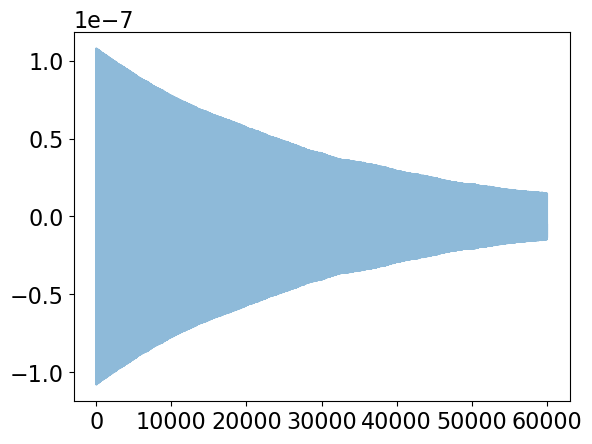

In [51]:
#%% plot one momentum as check
nfile=1
n_mom=0
moms= momenta_matrix_array[nfile,n_mom,:]
moms=np.sign(moms)*np.abs(moms)**1/float(n_mom+1)
print (intensity_array[nfile])
plt.close('all')
plt.figure()
plt.plot(moms, alpha=0.5)
plt.show()

In [52]:
#%%
## DOING THE FFTS
nturns = len(momenta_matrix_array[0][0,:])-1
n_points_fft = hamming(nturns) # it should be a Hamming number (product of only powers of 2, 3 and 5) for FFT speed up (never more than n_turn)
n_in = 0
n_fin = n_in + n_points_fft
# print('n_points_fft is a regular number: '+str(next_regular(n_points_fft)==n_points_fft))
n_file_min = 0
n_file_max = len(intensity_array)-1
#n_file_max = 20
#n_file_min = 30
#n_file_max = 40
max_ampl = 1e500 # 1e308 is finite, 1e309 is infinite
min_momentum = 0
max_momentum = 10
data_fft=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))
# data_fft2=np.zeros((n_file_max-n_file_min+1, int(n_points_fft/2)+1))

for i in range(n_file_max-n_file_min+1):
    momenta_matrix = momenta_matrix_array[i+n_file_min]
   # print ('Intensity = ', intensity_array[i+n_file_min])
    for i1 in range(min_momentum,max_momentum+1): 
        aux = np.sign(momenta_matrix[i1,n_in:n_fin])* \
                np.abs(momenta_matrix[i1,n_in:n_fin])**(1./(float(i1+1)))
        n1 = np.where((np.abs(aux)>max_ampl)|(np.isnan(aux))) 
        aux[n1] = 0
        aux1 = np.abs(np.fft.rfft(aux))
        # aux2 = np.imag(np.fft.rfft(aux))
        # aux2 = aux2/np.max(aux2)
        aux1 = aux1/np.max(aux1)
        data_fft[i,:] = data_fft[i,:] + aux1
        # data_fft2[i,:] = data_fft2[i,:] + aux2

freq = fftpack.rfftfreq(int(n_points_fft/2)+1, d=1)
x = (freq-Q_frac)/Q_s0
n_data = np.where(np.abs(x)<=1000)
x1 = x[n_data]
# print(freq)
# print(x)
# print(n_data)

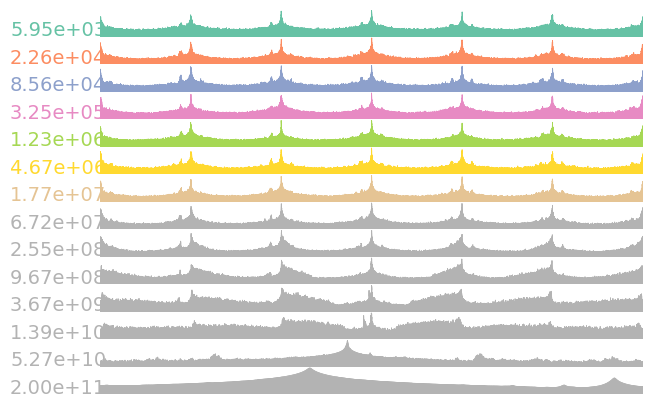

In [53]:
#%%
from cycler import cycler
import matplotlib.style
import matplotlib as mpl
# mpl.rcParams['axes.prop_cycle'] = cycler(color='bgrcmyk')
# T = Table()
plt.close('all')
### PLOT 1
#n_file_max = 3
#n_file_min = 0
# plt.figure(figsize=(8,2*(n_file_max-n_file_min+1)))
n = n_file_max-n_file_min+1
fig, axs = plt.subplots(nrows=n, ncols=1, 
                        figsize=(7,5), dpi=100,
                        subplot_kw={'xticks': [], 'yticks': []},
                        sharex=True)
plt.subplots_adjust(wspace=-0.2, hspace=0)
# axs[0].set_title('Frequency analysis as a function of bunch population')
colors = iter([plt.cm.Set2(i) for i in range(n_file_max-n_file_min+1)])
for i0 in range(n_file_max-n_file_min+1):
    # T_temp = Table()
    co = next(colors)
    # axs[i0].subplot(n_file_max-n_file_min+1,1,i0+1)
    axs[i0].tick_params(axis='both', which='both', labelsize=0, left=False)
    # plt.title('N_p = '+ str(intensity_array[i0+n_file_min]*1e-10), fontsize=10)
    y = np.abs(data_fft[i0])
    y1 = y[n_data]
    axs[i0].semilogy(x1,y1, linewidth=0.5, color=co)
    axs[i0].fill_between(x1,y1, linewidth=0.5, color=co)
    axs[i0].axhline(y=0, lw=2)
    # T_temp['x'] = x1
    # T_temp['y'] = y1
    # T_temp['Np'] = intensity_array[i0+n_file_min]
    # T = vstack([T, T_temp])
    axs[i0].set_xlim(-3,3)
    axs[i0].set_xlabel('')
    axs[i0].set_xticks([])
    # axs[i0].set_ylabel("{:.2e}".format(intensity_array[i0+n_file_min]), 
                    #    fontsize=10, rotation='horizontal', color=co)
    axs[i0].text(-4,min(y1),"{:.2e}".format(intensity_array[i0+n_file_min]), color=co)
    axs[i0].yaxis.labelpad = -100
    axs[i0].yaxis.set_label_coords(-.15, .1)
    # axs[i0].set_ylabel('')
    axs[i0].set_yticks([])
    axs[i0].spines['right'].set_visible(False)
    axs[i0].spines['top'].set_visible(False)
    axs[i0].spines['bottom'].set_visible(False)
    axs[i0].spines['left'].set_visible(False)
    # axs[i0].ticklabel_format(axis='y', useMathText=True, scilimits=(0,1))
    # axs[i0].yaxis.set_visible(False)
plt.tick_params(
    axis='y',          # changes apply to the x-axis
    which='both',      # both major and minor ticks are affected
    bottom=False,      # ticks along the bottom edge are off
    top=False,         # ticks along the top edge are off
    labelbottom=False) # labels along the bottom edge are off
# plt.tight_layout()
# plt.savefig('fft_inj90.pdf', dpi=300, bbox_inches='tight')
plt.show()

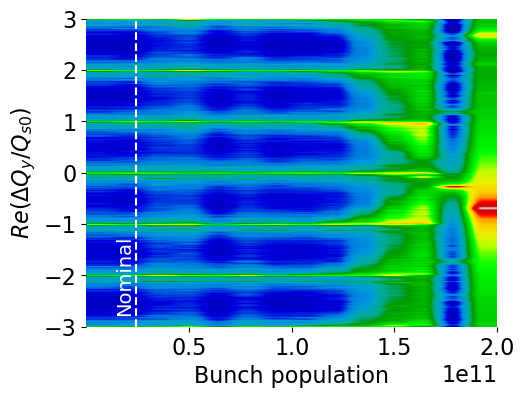

In [55]:
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.set_xlabel('Bunch population', fontsize=16)
ax.set_ylabel('$Re(\Delta Q_{y}/Q_{s0})$', fontsize=16)
plt.rc('xtick', labelsize=16)# Set the font size for x tick labels
plt.rc('ytick', labelsize=16)# Set the font size for y tick labels
 # Set the font family and size
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 14
#
Z_fft=np.zeros((len(n_data[0]), n_file_max-n_file_min+1))
for i0 in range(n_file_max-n_file_min+1):
    y = data_fft[i0]
    y = np.where(y==0, 1e-20, y)
    y = np.log10(y)
    Z_fft[:,i0] = y[n_data]
#
ax.imshow(Z_fft, origin='lower', interpolation='spline36', #vmin=-1., vmax=0.5,
	extent=[intensity_array[n_file_min], intensity_array[n_file_max], x1.min(), x1.max()], 
         cmap='nipy_spectral', aspect=25e9)
# ax.grid('on')
ax.set_ylim(-3,3)
ax.axvline(2.43e10, color='white', linestyle='--')
ax.text(1.4e10, -2.7, 'Nominal', rotation='vertical', color='white')
# plt.savefig('tmci_pa313.pdf', dpi=400, bbox_inches='tight')
plt.show()